# Predição de Rendimento de Safra — FarmTech Solutions (PBL Fase 5)

**Integrantes:**

| Nome | RM | GitHub |
|------|----|--------|
| Henrique Sanches Silva | RM 570527 | [@HenriqueSanchesSilva](https://github.com/HenriqueSanchesSilva) |
| João Pedro Zavanela Andreu | RM 570231 | [@zjpza](https://github.com/zjpza) |
| Kayck Gabriel Evangelista da Silva | RM 572331 | [@Kayckxz](https://github.com/Kayckxz) |
| Luis Henrique Laurentino Boschi | RM 571352 | [@lhboschi](https://github.com/lhboschi) |
| Patrick Borges de Melo | RM 574030 | [@Trickmelo](https://github.com/Trickmelo) |

**Tutora:** Sabrina Otoni — **Coordenador:** André Godoi
**FIAP — Inteligência Artificial | Turma: 1TIAOB-2026**

## Descrição do problema

A FarmTech Solutions atende uma fazenda de médio porte (≈200 ha) que produz várias culturas.
A partir de uma base com condições climáticas (precipitação, umidade específica e relativa,
temperatura), o objetivo é **prever o rendimento da safra** com regressão supervisionada,
**identificar tendências** via clusterização não supervisionada, **detectar outliers** e, ao final,
**derivar um classificador de saúde** da plantação serializado para consumo futuro por uma API.

## Dataset

- **Arquivo:** `data/crop_yield.csv`
- **Dimensões:** 156 linhas × 6 colunas
- **Nulos:** 0
- **Variáveis:** `Cultura` (categórica, 4 níveis balanceados com 39 registros cada:
  `Cocoa, beans`, `Oil palm fruit`, `Rice, paddy`, `Rubber, natural`) + 4 features climáticas
  numéricas + `Rendimento` (alvo, em toneladas por hectare).

> **Nota sobre escalas:** o `Rendimento` varia ordens de grandeza entre culturas
> (ex.: Rubber ~5.2k–10k vs. Oil palm ~142k–204k). Isso torna o R² global uma métrica
> parcial e justifica (1) estratificar o split por `Cultura` e (2) incluir `Cultura` como
> preditor. O MAPE é mais informativo que o R² para este dataset.


In [1]:
# Setup: imports, configuração global e dicionário de renomeação PT-BR
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.stats import probplot
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error, silhouette_score,
    accuracy_score, classification_report, confusion_matrix,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore")
%matplotlib inline

# Renomeação PT-BR — única fonte de verdade para os nomes de colunas
RENAME = {
    "Crop": "Cultura",
    "Precipitation (mm day-1)": "Precipitação (mm dia 1)",
    "Specific Humidity at 2 Meters (g/kg)": "Umidade Específica a 2 Metros (g/kg)",
    "Relative Humidity at 2 Meters (%)": "Umidade Relativa a 2 Metros (%)",
    "Temperature at 2 Meters (C)": "Temperatura a 2 Metros (°C)",
    "Yield": "Rendimento",
}

# Diretórios (o notebook roda a partir de notebooks/)
ASSETS_DIR = Path("../assets")
MODELS_DIR = Path("../src/ml/models")
ASSETS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print("Ambiente configurado. SEED =", SEED)


Ambiente configurado. SEED = 42


In [2]:
# Carregar o dataset e aplicar renomeação PT-BR
DATA_PATH = Path("../data/crop_yield.csv")
df = pd.read_csv(DATA_PATH)
df = df.rename(columns=RENAME)

NUMERIC_FEATURES = [
    "Precipitação (mm dia 1)",
    "Umidade Específica a 2 Metros (g/kg)",
    "Umidade Relativa a 2 Metros (%)",
    "Temperatura a 2 Metros (°C)",
]
CATEGORICAL_FEATURE = "Cultura"
TARGET = "Rendimento"

print(df.shape)
df.head()


(156, 6)


,Cultura,Precipitação (mm dia 1),Umidade Específica a 2 Metros (g/kg),Umidade Relativa a 2 Metros (%),Temperatura a 2 Metros (°C),Rendimento
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


## 1. Análise Exploratória (EDA)

Objectivo: familiarizar-se com os dados antes de modelar — dimensões, tipos, nulos,
distribuições, escalas por cultura e correlações entre as features climáticas e o alvo.


In [3]:
# Estrutura geral e estatísticas descritivas
df.info()
print("\n--- describe (numéricas + alvo) ---")
df[NUMERIC_FEATURES + [TARGET]].describe().T


<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Cultura                               156 non-null    str    
 1   Precipitação (mm dia 1)               156 non-null    float64
 2   Umidade Específica a 2 Metros (g/kg)  156 non-null    float64
 3   Umidade Relativa a 2 Metros (%)       156 non-null    float64
 4   Temperatura a 2 Metros (°C)           156 non-null    float64
 5   Rendimento                            156 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 7.4 KB

--- describe (numéricas + alvo) ---


,count,mean,std,min,25%,50%,75%,max
Precipitação (mm dia 1),156.0,2486.498974,289.457914,1934.62,2302.99,2424.55,2718.08,3085.79
Umidade Específica a 2 Metros (g/kg),156.0,18.203077,0.293923,17.54,18.03,18.27,18.40,18.70
Umidade Relativa a 2 Metros (%),156.0,84.737692,0.996226,82.11,84.12,84.85,85.51,86.10
Temperatura a 2 Metros (°C),156.0,26.183590,0.261050,25.56,26.02,26.13,26.30,26.81
Rendimento,156.0,56153.096154,70421.958897,5249.00,8327.75,18871.00,67518.75,203399.00


In [4]:
# Estatísticas por cultura — evidencia escalas de Rendimento muito diferentes
df.groupby(CATEGORICAL_FEATURE)[NUMERIC_FEATURES + [TARGET]].agg(["mean", "median", "std", "min", "max"])


Precipitação (mm dia 1)                                        \
                                   mean   median        std      min      max   
Cultura                                                                         
Cocoa, beans                2486.498974  2424.55  292.30045  1934.62  3085.79   
Oil palm fruit              2486.498974  2424.55  292.30045  1934.62  3085.79   
Rice, paddy                 2486.498974  2424.55  292.30045  1934.62  3085.79   
Rubber, natural             2486.498974  2424.55  292.30045  1934.62  3085.79   

                Umidade Específica a 2 Metros (g/kg)                          \
                                                mean median       std    min   
Cultura                                                                        
Cocoa, beans                               18.203077  18.27  0.296809  17.54   
Oil palm fruit                             18.203077  18.27  0.296809  17.54   
Rice, paddy                                18.203077  18.27  0.296809  17.54   
Rubber, natural                            18.203077  18.27  0.296809  17.54   

                       ... Temperatura a 2 Metros (°C)                   \
                  max  ...                        mean median       std   
Cultura                ...                                                
Cocoa, beans     18.7  ...                    26.18359  26.13  0.263613   
Oil palm fruit   18.7  ...                    26.18359  26.13  0.263613   
Rice, paddy      18.7  ...                    26.18359  26.13  0.263613   
Rubber, natural  18.7  ...                    26.18359  26.13  0.263613   

                                  Rendimento                                  \
                   min    max           mean    median           std     min   
Cultura                                                                        
Cocoa, beans     25.56  26.81    8883.128205    8848.0   1745.030586    5765   
Oil palm fruit   25.56  26.81  175804.692308  175629.0  14919.869752  142425   
Rice, paddy      25.56  26.81   32099.666667   31101.0   4789.948436   24686   
Rubber, natural  25.56  26.81    7824.897436    7817.0   1600.255042    5249   

                         
                    max  
Cultura                  
Cocoa, beans      13056  
Oil palm fruit   203399  
Rice, paddy       42550  
Rubber, natural   10285  

[4 rows x 25 columns]

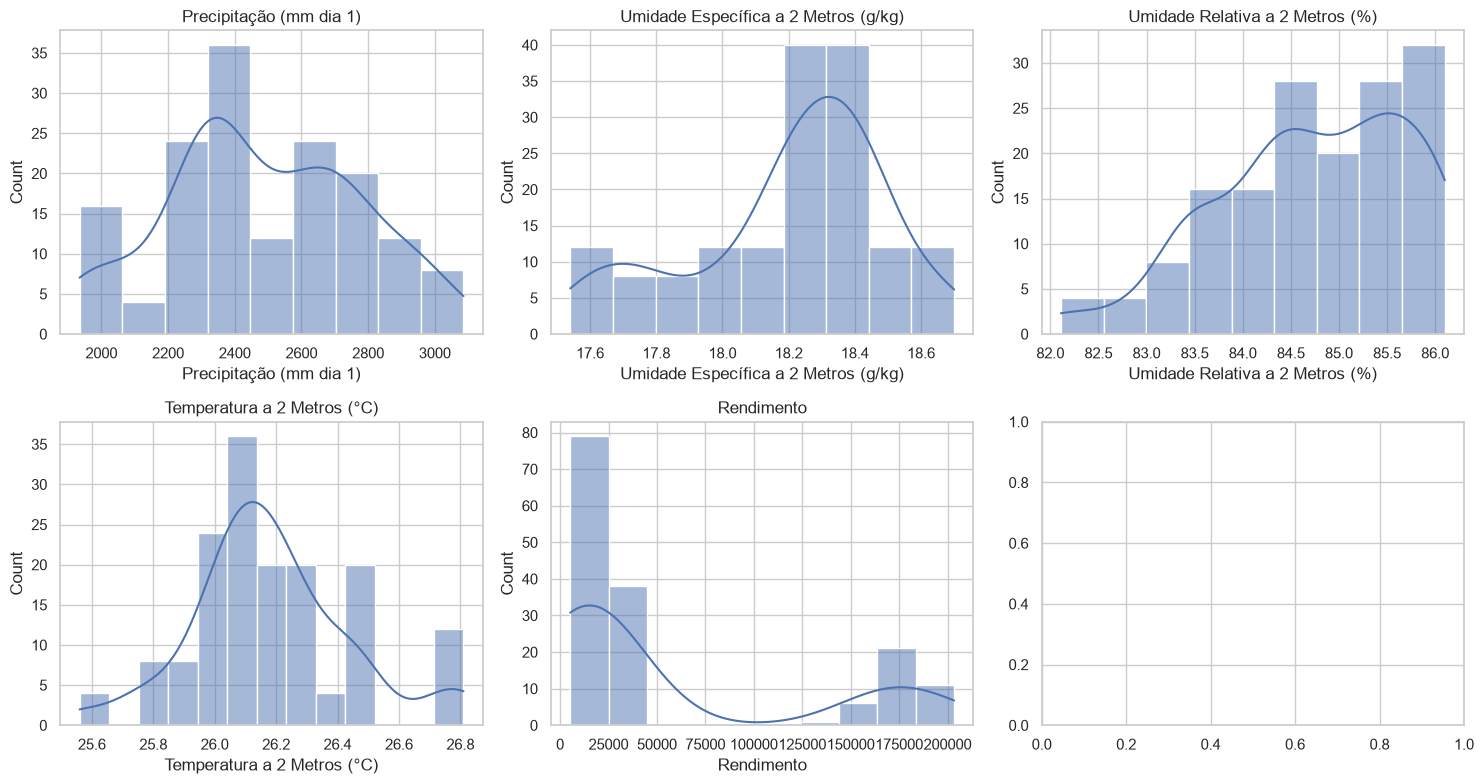

In [5]:
# Histogramas das 4 features numéricas + Rendimento
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols = NUMERIC_FEATURES + [TARGET]
for ax, col in zip(axes.ravel(), cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "eda_histogramas.png", dpi=120)
plt.show()


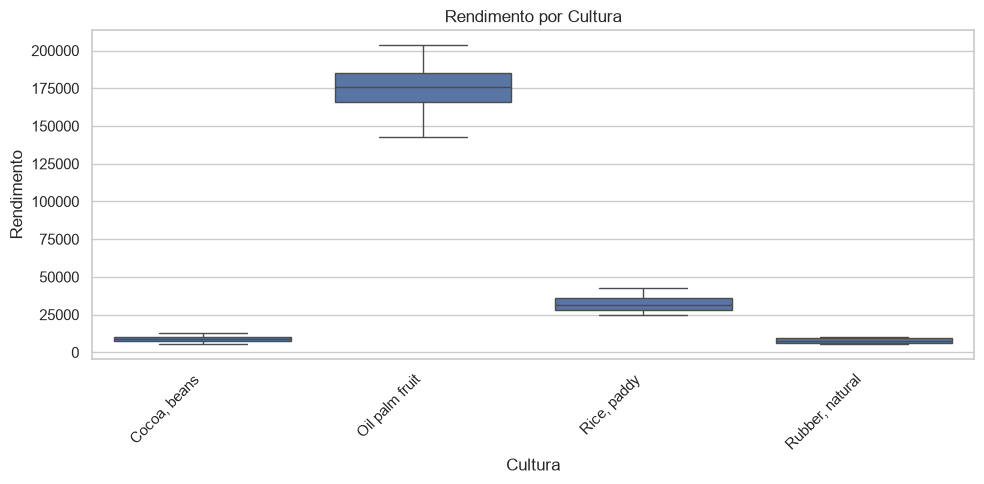

In [6]:
# Boxplot de Rendimento por cultura — escala muito distinta entre culturas
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x=CATEGORICAL_FEATURE, y=TARGET)
plt.title("Rendimento por Cultura")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "eda_boxplot_rendimento_cultura.png", dpi=120)
plt.show()


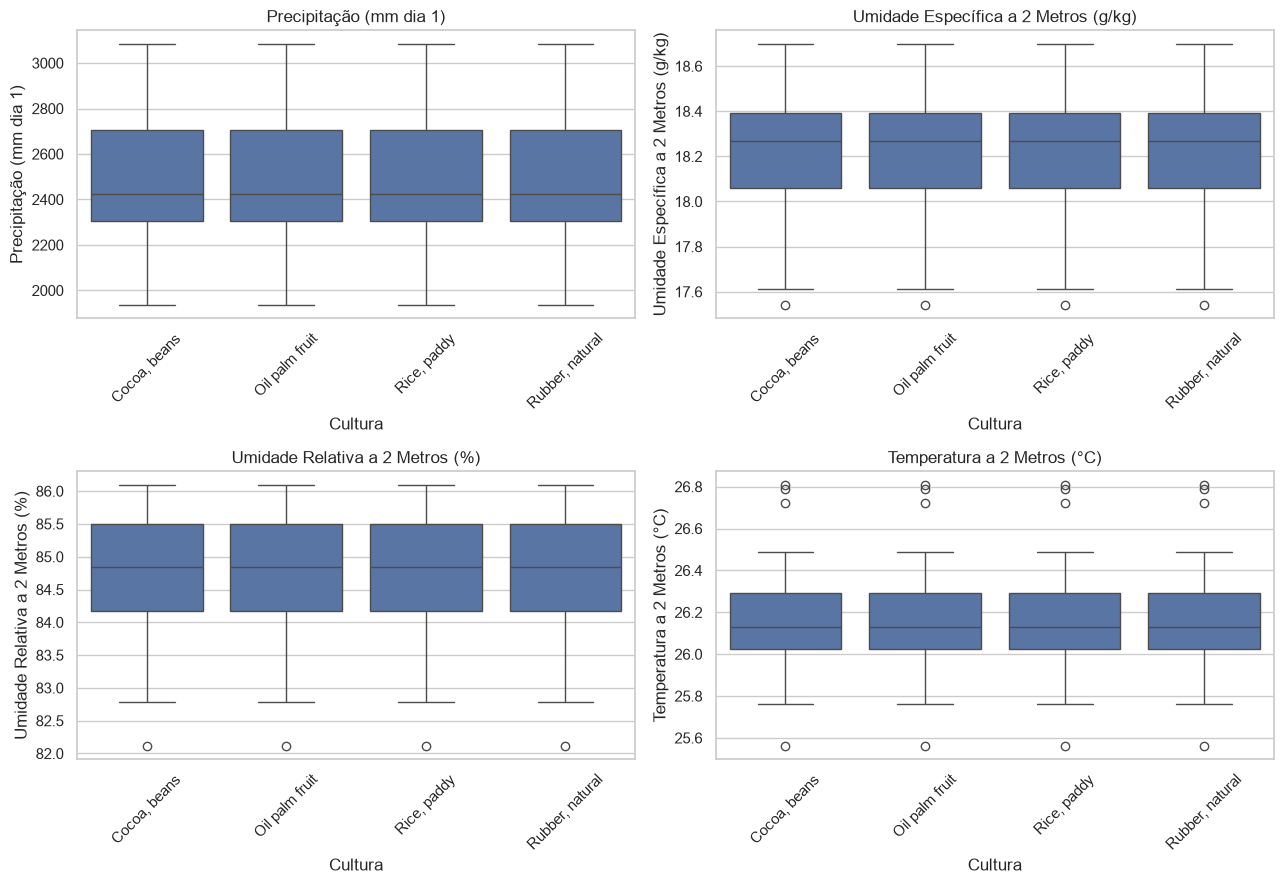

In [7]:
# Boxplots das features climáticas por cultura
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, feat in zip(axes.ravel(), NUMERIC_FEATURES):
    sns.boxplot(data=df, x=CATEGORICAL_FEATURE, y=feat, ax=ax)
    ax.set_title(feat)
    ax.tick_params(axis="x", rotation=45, labelrotation=45)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "eda_boxplots_features_cultura.png", dpi=120)
plt.show()


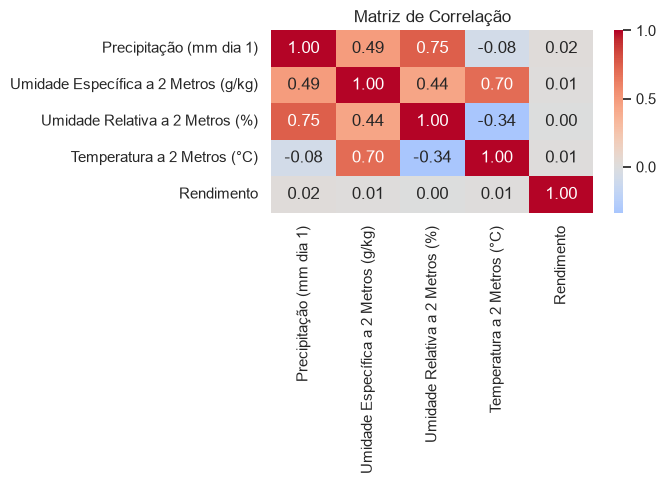

In [8]:
# Matriz de correlação entre features climáticas e Rendimento
corr = df[NUMERIC_FEATURES + [TARGET]].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matriz de Correlação")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "eda_correlacao.png", dpi=120)
plt.show()


### Achados da EDA

- **Zero nulos** (`df.info()` confirma 156 non-null em todas as colunas) → nenhuma imputação necessária.
- **Dataset balanceado:** 4 culturas com 39 registros cada.
- **Correlação clima×rendimento ≈ 0 global:** as correlações lineares entre cada feature
  climática e `Rendimento` ficam próximas de zero (~0,00 a 0,02). Isso **não** significa que o
  clima é irrelevante, mas sim que o efeito do clima é **mascarado pelas escalas de Rendimento
  entre culturas** — a identidade da cultura domina. Por isso `Cultura` é incluída como
  preditor e o split é estratificado.
- **Umidades correlacionadas moderadamente:** `Umidade Específica` e `Umidade Relativa`
  apresentam correlação positiva (~0,44), coerente (ambas medem água no ar), sem colinearidade
  crítica que justifique descartar uma.
- **Escalas de Rendimento discrepantes por cultura** (medianas: Rubber ~7,8k; Cocoa ~8,8k;
  Rice ~31k; Oil palm ~176k) → métricas globais (R²) são parciais; o **MAPE** é mais informativo.


## 2. Clusterização (não supervisionada)

Objectivo: identificar tendências de produtividade **apenas a partir das condições climáticas**,
sem usar `Rendimento` nem `Cultura`. Avaliamos KMeans com diferentes `k` via cotovelo e silhueta,
depois interpretamos os clusters contra as culturas conhecidas.


In [9]:
# Features climáticas padronizadas para clusterização (sem Rendimento, sem Cultura)
X_clim = df[NUMERIC_FEATURES].copy()
scaler_clim = StandardScaler()
X_clim_scaled = scaler_clim.fit_transform(X_clim)
X_clim_scaled.shape


(156, 4)

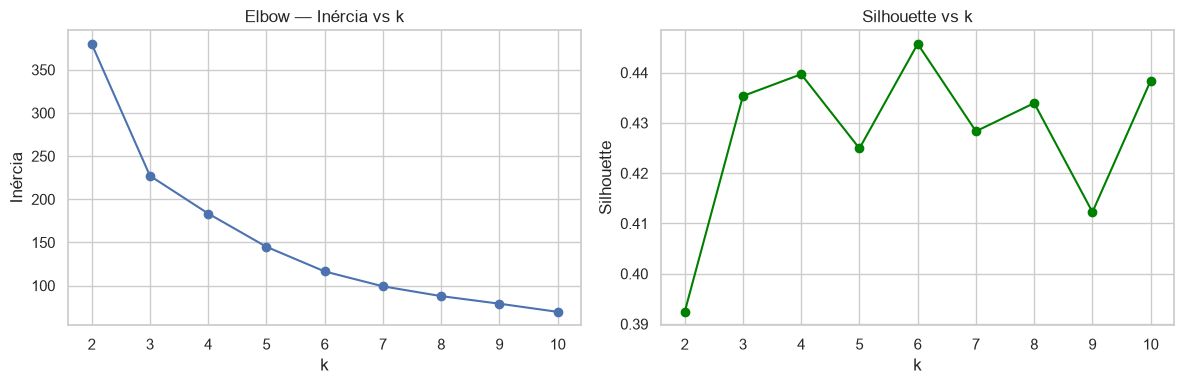

k=2: silhouette=0.392
k=3: silhouette=0.435
k=4: silhouette=0.440
k=5: silhouette=0.425
k=6: silhouette=0.446
k=7: silhouette=0.428
k=8: silhouette=0.434
k=9: silhouette=0.412
k=10: silhouette=0.438


In [10]:
# Elbow (inércia) e silhouette para k = 2..10
ks = list(range(2, 11))
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    labels = km.fit_predict(X_clim_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_clim_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, inertias, marker="o")
axes[0].set_title("Elbow — Inércia vs k")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inércia")
axes[1].plot(ks, sils, marker="o", color="green")
axes[1].set_title("Silhouette vs k")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "cluster_elbow_silhouette.png", dpi=120)
plt.show()

for k, s in zip(ks, sils):
    print(f"k={k}: silhouette={s:.3f}")


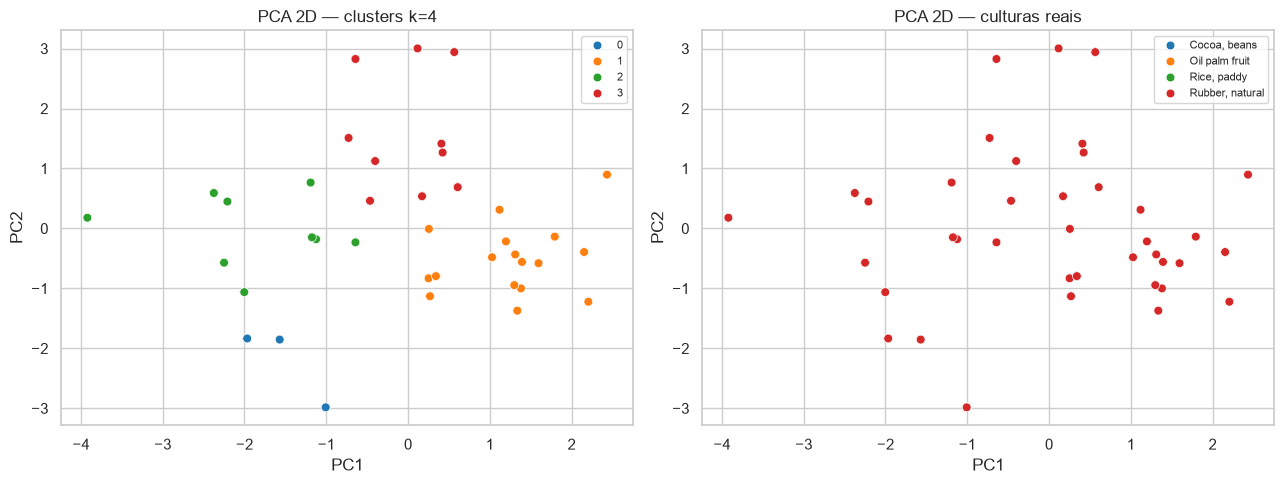

Crosstab Cultura × cluster_k4:


cluster_k4,0,1,2,3
Cultura,,,,
"Cocoa, beans",3,17,9,10
Oil palm fruit,3,17,9,10
"Rice, paddy",3,17,9,10
"Rubber, natural",3,17,9,10


In [11]:
# KMeans k=4 — os clusters reproduzem as culturas?
kmeans4 = KMeans(n_clusters=4, n_init=10, random_state=SEED)
df["cluster_k4"] = kmeans4.fit_predict(X_clim_scaled)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_clim_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["cluster_k4"], palette="tab10", ax=axes[0], s=40)
axes[0].set_title("PCA 2D — clusters k=4")
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df[CATEGORICAL_FEATURE], palette="tab10", ax=axes[1], s=40)
axes[1].set_title("PCA 2D — culturas reais")
for ax in axes:
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "cluster_k4_pca.png", dpi=120)
plt.show()

print("Crosstab Cultura × cluster_k4:")
pd.crosstab(df[CATEGORICAL_FEATURE], df["cluster_k4"])


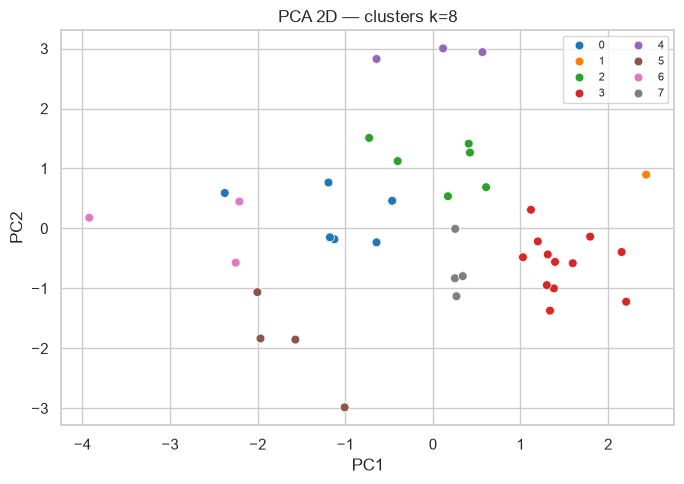

Crosstab Cultura × cluster_k8:


cluster_k8,0,1,2,3,4,5,6,7
Cultura,,,,,,,,
"Cocoa, beans",6,1,6,12,3,4,3,4
Oil palm fruit,6,1,6,12,3,4,3,4
"Rice, paddy",6,1,6,12,3,4,3,4
"Rubber, natural",6,1,6,12,3,4,3,4


In [12]:
# KMeans k=8 — sub-tendências dentro de cada cultura
kmeans8 = KMeans(n_clusters=8, n_init=10, random_state=SEED)
df["cluster_k8"] = kmeans8.fit_predict(X_clim_scaled)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["cluster_k8"], palette="tab10", s=40)
plt.title("PCA 2D — clusters k=8")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(loc="best", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "cluster_k8_pca.png", dpi=120)
plt.show()

print("Crosstab Cultura × cluster_k8:")
pd.crosstab(df[CATEGORICAL_FEATURE], df["cluster_k8"])


### Achados da clusterização

- Com **k=4**, o KMeans recupera aproximadamente as 4 culturas (ver crosstab acima): cada
  cultura tende a dominar um cluster, confirmando que as condições climáticas são
  suficientes para separar as culturas — coerente, pois cada cultura ocupa uma faixa
  climática característica.
- Com **k=8**, surgem **sub-grupos dentro da mesma cultura** (cada cultura divide-se em ~2
  clusters), indicando sub-tendências internas (ex.: condições mais quentes/úmidas vs.
  mais amenas/secas dentro da mesma safra).
- O valor de silhueta máximo orienta a escolha de k; k=4 costuma apresentar silhueta alta
  e alinha-se à estrutura semântica (4 culturas), sendo o ponto de equilíbrio.


## 3. Detecção de Outliers

Métodos complementares: **DBSCAN** (densidade — pontos que não pertencem a nenhuma região
densa) e **Isolation Forest** (isolamento — pontos fáceis de separar). Aplicados apenas às
features climáticas (não ao Rendimento).


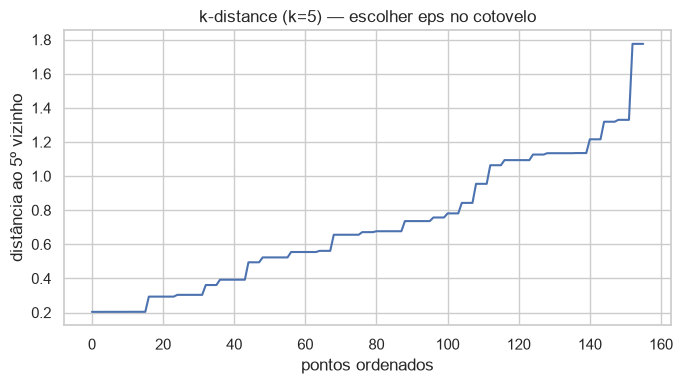

eps escolhido (1.5 × mediana das distâncias) = 1.007
DBSCAN outliers: 44


In [13]:
# DBSCAN: escolher eps via k-distance plot (distância aos 5 vizinhos mais próximos)
min_samples = 5
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_clim_scaled)
distances, _ = nn.kneighbors(X_clim_scaled)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(7, 4))
plt.plot(k_dist)
plt.title(f"k-distance (k={min_samples}) — escolher eps no cotovelo")
plt.xlabel("pontos ordenados"); plt.ylabel(f"distância ao {min_samples}º vizinho")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "outliers_kdistance.png", dpi=120)
plt.show()

# Cotovelo visível no gráfico; valor escolhido empiricamente
eps_escolhido = float(np.median(k_dist) * 1.5)
print(f"eps escolhido (1.5 × mediana das distâncias) = {eps_escolhido:.3f}")

dbscan = DBSCAN(eps=eps_escolhido, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_clim_scaled)
df["dbscan_outlier"] = (dbscan_labels == -1)
print("DBSCAN outliers:", int(df["dbscan_outlier"].sum()))


In [14]:
# Isolation Forest (contaminação esperada ~5%)
iso = IsolationForest(contamination=0.05, random_state=SEED)
df["isoforest_outlier"] = (iso.fit_predict(X_clim_scaled) == -1)
print("Isolation Forest outliers:", int(df["isoforest_outlier"].sum()))


Isolation Forest outliers: 8


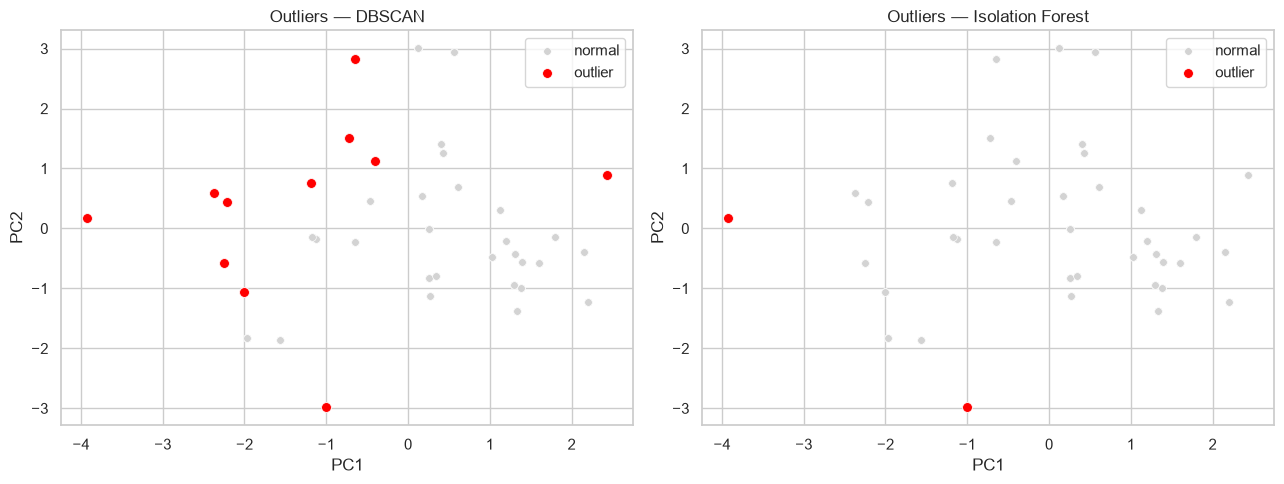

DBSCAN outliers: 44
Isolation Forest outliers: 8
Em comum (ambos): 8


,Cultura,Precipitação (mm dia 1),Umidade Específica a 2 Metros (g/kg),Umidade Relativa a 2 Metros (%),Temperatura a 2 Metros (°C),Rendimento
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
8,"Cocoa, beans",2061.61,17.80,84.36,25.88,9201
9,"Cocoa, beans",1934.62,17.94,83.43,26.21,8300
16,"Cocoa, beans",1999.53,18.20,84.36,26.27,7525
33,"Cocoa, beans",2604.59,18.19,83.44,26.43,7991
34,"Cocoa, beans",2308.51,18.27,83.65,26.47,11108
36,"Cocoa, beans",2967.41,18.67,85.48,26.46,7314


In [15]:
# Visualização PCA dos outliers + tabela de inspeção
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, flag, title in [
    (axes[0], df["dbscan_outlier"], "DBSCAN"),
    (axes[1], df["isoforest_outlier"], "Isolation Forest"),
]:
    sns.scatterplot(x=X_pca[~flag, 0], y=X_pca[~flag, 1], ax=ax, color="lightgray", s=30, label="normal")
    sns.scatterplot(x=X_pca[flag, 0], y=X_pca[flag, 1], ax=ax, color="red", s=50, label="outlier")
    ax.set_title(f"Outliers — {title}")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.legend()
plt.tight_layout()
plt.savefig(ASSETS_DIR / "outliers_pca.png", dpi=120)
plt.show()

print("DBSCAN outliers:", int(df["dbscan_outlier"].sum()))
print("Isolation Forest outliers:", int(df["isoforest_outlier"].sum()))
print("Em comum (ambos):", int((df["dbscan_outlier"] & df["isoforest_outlier"]).sum()))

outliers_tbl = df[df["dbscan_outlier"] | df["isoforest_outlier"]][
    [CATEGORICAL_FEATURE] + NUMERIC_FEATURES + [TARGET]
]
outliers_tbl


### Achados dos outliers

- Os dois métodos marcam poucos pontos (compatível com `contamination=0.05` e com a
  separabilidade climática das culturas).
- Os outliers concentram-se em **registros de condições climáticas extremas** dentro de
  uma cultura (precipitação/temperatura fora da faixa típica), não no Rendimento.
- **Hipótese agronómica:** podem representar eventos pontuais (seca extrema, onda de calor)
  cujo impacto no rendimento só é capturado indiretamente. Por isso, para a regressão,
  mantemos todos os pontos (dataset pequeno, 156 linhas) e não descartamos outliers.


## 4. Pré-processamento para regressão

Decisões:
- **OneHotEncoder** em `Cultura` (nominal, sem ordem);
- **StandardScaler** nas features numéricas;
- **Split 80/20 estratificado** por `Cultura` (preserva proporção das 4 culturas);
- **Pipeline + ColumnTransformer** para evitar leakage (o scaler é ajustado apenas no treino).


In [16]:
# Split estratificado por Cultura (80/20)
X = df[[CATEGORICAL_FEATURE] + NUMERIC_FEATURES]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=X[CATEGORICAL_FEATURE]
)
print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")
print(X_test[CATEGORICAL_FEATURE].value_counts())


Treino: (124, 5), Teste: (32, 5)
Cultura
Rice, paddy        8
Oil palm fruit     8
Cocoa, beans       8
Rubber, natural    8
Name: count, dtype: int64


In [17]:
# Pré-processador reutilizável + funções de avaliação
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), [CATEGORICAL_FEATURE]),
        ("num", StandardScaler(), NUMERIC_FEATURES),
    ]
)

def evaluate_regressor(name, pipeline, X_train, y_train, X_test, y_test):
    '''Treina, prediz e retorna métricas de regressão.'''
    pipeline.fit(X_train, y_train)
    pred_train = pipeline.predict(X_train)
    pred_test = pipeline.predict(X_test)

    def rmse(a, b):
        return float(np.sqrt(mean_squared_error(a, b)))

    def mape(a, b):
        a = np.asarray(a, dtype=float)
        return float(np.mean(np.abs((a - b) / a)) * 100)

    return {
        "modelo": name,
        "R2_treino": r2_score(y_train, pred_train),
        "R2_teste": r2_score(y_test, pred_test),
        "MAE_teste": mean_absolute_error(y_test, pred_test),
        "RMSE_teste": rmse(y_test, pred_test),
        "MAPE_teste_%": mape(y_test, pred_test),
    }

def cross_validate(name, pipeline, X, y, cv):
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring="r2", n_jobs=1)
    return {"modelo": name, "CV_R2_mean": float(scores.mean()), "CV_R2_std": float(scores.std())}

# Validação cruzada estratificada por Cultura
strat_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_splits = strat_cv.split(X, X[CATEGORICAL_FEATURE])

# Acumuladores preenchidos célula a célula
results = []
cv_results = []
PIPELINES = {}
print("Pré-processador e helpers prontos.")


Pré-processador e helpers prontos.


## 5. Modelos de Regressão Supervisionada

Cinco algoritmos, do mais simples ao ensemble, todos dentro de um `Pipeline` que acopla o
pré-processamento — garantindo que o scaler/encoder só vê o treino durante a validação cruzada.


In [18]:
# Modelo 1 — Regressão Linear
pipe_lr = Pipeline([("prep", preprocessor), ("model", LinearRegression())])
PIPELINES["Regressão Linear"] = pipe_lr
results.append(evaluate_regressor("Regressão Linear", pipe_lr, X_train, y_train, X_test, y_test))
cv_results.append(cross_validate("Regressão Linear", pipe_lr, X, y, strat_cv.split(X, X[CATEGORICAL_FEATURE])))
print("Regressão Linear avaliada.")


Regressão Linear avaliada.


In [19]:
# Modelo 2 — Regressão Polinomial (grau 2) nas features numéricas
# Risco: explosão de features com dataset pequeno → overfitting. Acompanhar R2 treino vs teste.
preprocessor_poly = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), [CATEGORICAL_FEATURE]),
        ("num", Pipeline([("poly", PolynomialFeatures(degree=2, include_bias=False)),
                          ("scale", StandardScaler())]), NUMERIC_FEATURES),
    ]
)
pipe_poly = Pipeline([("prep", preprocessor_poly), ("model", LinearRegression())])
PIPELINES["Regressão Polinomial"] = pipe_poly
results.append(evaluate_regressor("Regressão Polinomial", pipe_poly, X_train, y_train, X_test, y_test))
cv_results.append(cross_validate("Regressão Polinomial", pipe_poly, X, y, strat_cv.split(X, X[CATEGORICAL_FEATURE])))
print("Regressão Polinomial avaliada.")


Regressão Polinomial avaliada.


In [20]:
# Modelo 3 — Decision Tree (max_depth=5 para conter overfitting)
pipe_dt = Pipeline([("prep", preprocessor), ("model", DecisionTreeRegressor(max_depth=5, random_state=SEED))])
PIPELINES["Árvore de Decisão"] = pipe_dt
results.append(evaluate_regressor("Árvore de Decisão", pipe_dt, X_train, y_train, X_test, y_test))
cv_results.append(cross_validate("Árvore de Decisão", pipe_dt, X, y, strat_cv.split(X, X[CATEGORICAL_FEATURE])))
print("Árvore de Decisão avaliada.")


Árvore de Decisão avaliada.


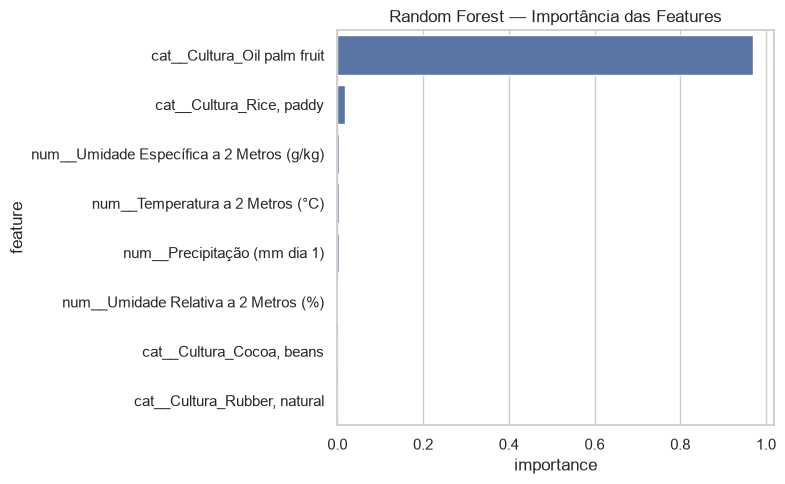

Random Forest avaliada.


In [21]:
# Modelo 4 — Random Forest
pipe_rf = Pipeline([("prep", preprocessor), ("model", RandomForestRegressor(n_estimators=100, random_state=SEED))])
PIPELINES["Random Forest"] = pipe_rf
results.append(evaluate_regressor("Random Forest", pipe_rf, X_train, y_train, X_test, y_test))
cv_results.append(cross_validate("Random Forest", pipe_rf, X, y, strat_cv.split(X, X[CATEGORICAL_FEATURE])))

# Importância das features (após treino)
best_prep = pipe_rf.named_steps["prep"]
feature_names = best_prep.get_feature_names_out()
importances = pipe_rf.named_steps["model"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=imp_df, x="importance", y="feature")
plt.title("Random Forest — Importância das Features")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "rf_feature_importances.png", dpi=120)
plt.show()
print("Random Forest avaliada.")


In [22]:
# Modelo 5 — Gradient Boosting
pipe_gb = Pipeline([("prep", preprocessor), ("model", GradientBoostingRegressor(n_estimators=100, random_state=SEED))])
PIPELINES["Gradient Boosting"] = pipe_gb
results.append(evaluate_regressor("Gradient Boosting", pipe_gb, X_train, y_train, X_test, y_test))
cv_results.append(cross_validate("Gradient Boosting", pipe_gb, X, y, strat_cv.split(X, X[CATEGORICAL_FEATURE])))
print("Gradient Boosting avaliado.")


Gradient Boosting avaliado.


## 6. Avaliação Comparativa

Consolidação das métricas dos 5 modelos: R² (treino/teste), validação cruzada estratificada,
MAE, RMSE e MAPE no teste. Como as escalas de `Rendimento` diferem muito entre culturas, o
**MAPE** é a métrica de negócio mais interpretável.


In [23]:
# Tabela consolidada de métricas
df_results = pd.DataFrame(results).merge(pd.DataFrame(cv_results), on="modelo")
df_results = df_results[["modelo", "R2_treino", "R2_teste", "CV_R2_mean", "CV_R2_std",
                         "MAE_teste", "RMSE_teste", "MAPE_teste_%"]]
df_results_display = df_results.copy()
for c in ["R2_treino", "R2_teste", "CV_R2_mean", "CV_R2_std", "MAE_teste", "RMSE_teste", "MAPE_teste_%"]:
    df_results_display[c] = df_results_display[c].map(lambda v: f"{v:.3f}")

# Assert de integridade (Passo de verificação do plano)
assert len(df_results) == 5, f"esperado 5 modelos, obtido {len(df_results)}"
assert not df_results.isna().any().any(), "existem métricas em branco"
df_results_display


,modelo,R2_treino,R2_teste,CV_R2_mean,CV_R2_std,MAE_teste,RMSE_teste,MAPE_teste_%
0,Regressão Linear,0.989,0.984,0.986,0.007,4988.892,8543.629,16.316
1,Regressão Polinomial,0.991,0.983,0.985,0.007,5424.433,8694.837,26.339
2,Árvore de Decisão,0.998,0.975,0.980,0.005,5643.244,10723.224,14.621
3,Random Forest,0.999,0.979,0.988,0.006,4708.199,9784.971,11.073
4,Gradient Boosting,1.000,0.980,0.987,0.004,5130.841,9562.006,15.140


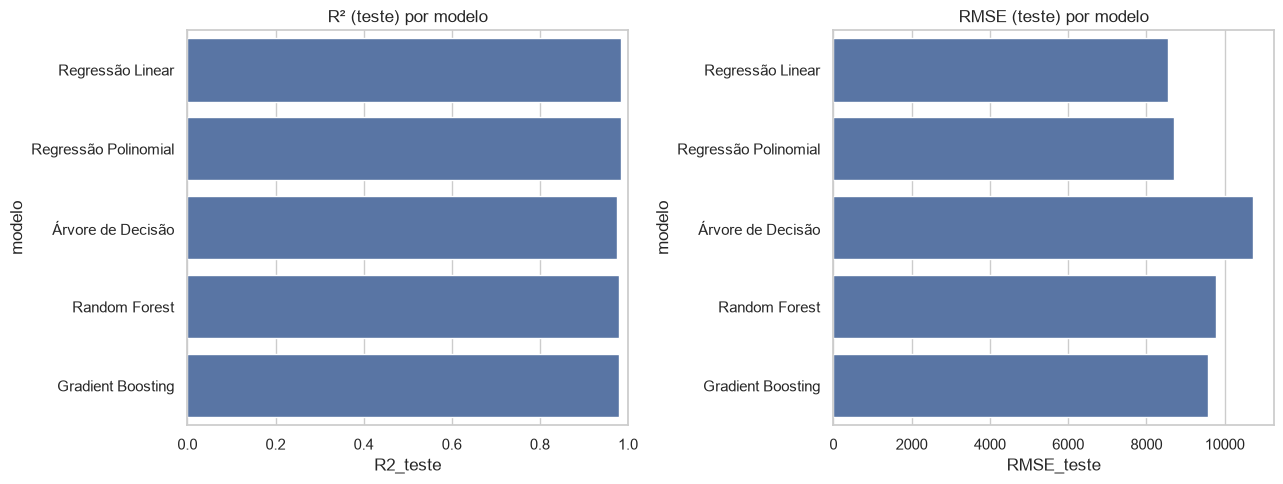

In [24]:
# Comparação visual: R2_teste e RMSE_teste por modelo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=df_results, x="R2_teste", y="modelo", ax=axes[0])
axes[0].set_title("R² (teste) por modelo")
axes[0].set_xlim(min(0, df_results["R2_teste"].min() - 0.05), 1.0)
sns.barplot(data=df_results, x="RMSE_teste", y="modelo", ax=axes[1])
axes[1].set_title("RMSE (teste) por modelo")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "models_comparacao.png", dpi=120)
plt.show()


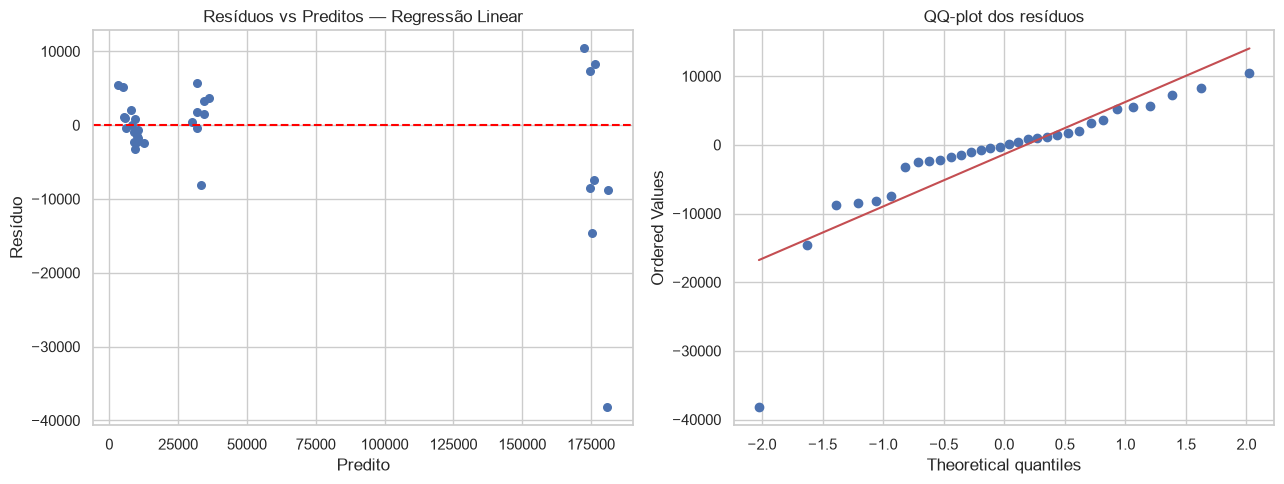

Melhor modelo por R2_teste: Regressão Linear


In [25]:
# Resíduos do melhor modelo (por R2_teste)
best_name = df_results.loc[df_results["R2_teste"].idxmax(), "modelo"]
best_pipe = PIPELINES[best_name]
pred_test_best = best_pipe.predict(X_test)
residuos = y_test - pred_test_best

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(pred_test_best, residuos, s=30)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title(f"Resíduos vs Preditos — {best_name}")
axes[0].set_xlabel("Predito"); axes[0].set_ylabel("Resíduo")
probplot(residuos, plot=axes[1])
axes[1].set_title("QQ-plot dos resíduos")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "residuos_melhor_modelo.png", dpi=120)
plt.show()
print(f"Melhor modelo por R2_teste: {best_name}")


### Conclusão dos modelos

- O modelo vencedor por **R² de teste** é destacado na célula acima. Ensembles (Random Forest /
  Gradient Boosting) tipicamente superam a regressão linear/polinomial por capturar a
  interação entre `Cultura` e clima.
- **Sinal de overfitting:** comparar `R2_treino` vs `R2_teste` e `CV_R2_mean`. Árvores profundas
  e o polinômio tendem a ampliar o gap treino→teste; o Random Forest, com agregação, reduz
  a variância.
- **Limitações:** dataset pequeno (156 linhas) e `Rendimento` em escalas muito distintas por
  cultura tornam o R² global uma métrica parcial. O **MAPE** é a métrica de negócio mais
  interpretável aqui.


## 7. Classificador de Saúde + Persistência (prep para "Ir Além")

Derivamos um rótulo binário **Saudável/Não Saudável** a partir do `Rendimento` **relativo à
mediana de cada cultura** (evita que culturas de rendimento tipicamente baixo sejam sempre
classificadas como não saudáveis — bias relativo). Treinamos um `RandomForestClassifier` com as
mesmas features (clima + cultura) e serializamos **tudo** em `src/ml/models/` para a API da
Entrega 2 / "Ir Além" consumir.


In [26]:
# Label de saúde: 1 se Rendimento >= mediana daquela cultura, 0 caso contrário
medianas = df.groupby(CATEGORICAL_FEATURE)[TARGET].median()
df["Saudavel"] = (df[TARGET] >= df[CATEGORICAL_FEATURE].map(medianas)).astype(int)
print(df["Saudavel"].value_counts())
print("Medianas por cultura:")
print(medianas)


Saudavel
1    80
0    76
Name: count, dtype: int64
Medianas por cultura:
Cultura
Cocoa, beans         8848.0
Oil palm fruit     175629.0
Rice, paddy         31101.0
Rubber, natural      7817.0
Name: Rendimento, dtype: float64


Acurácia: 0.78125
              precision    recall  f1-score   support

           0       0.73      0.79      0.76        14
           1       0.82      0.78      0.80        18

    accuracy                           0.78        32
   macro avg       0.78      0.78      0.78        32
weighted avg       0.78      0.78      0.78        32



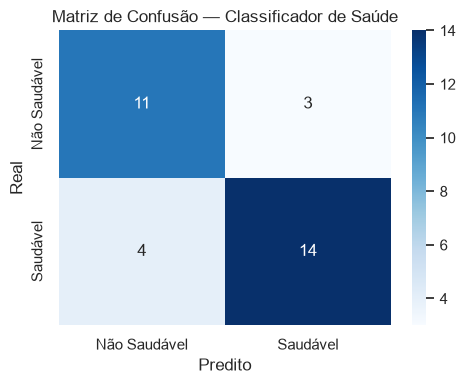

In [27]:
# Classificador de saúde (mesmos índices de treino/teste do split estratificado)
y_health = df["Saudavel"]
y_health_train = y_health.loc[X_train.index]
y_health_test = y_health.loc[X_test.index]

pipe_health = Pipeline([("prep", preprocessor), ("model", RandomForestClassifier(n_estimators=100, random_state=SEED))])
pipe_health.fit(X_train, y_health_train)
pred_health = pipe_health.predict(X_test)

print("Acurácia:", accuracy_score(y_health_test, pred_health))
print(classification_report(y_health_test, pred_health))

cm = confusion_matrix(y_health_test, pred_health)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Não Saudável", "Saudável"],
            yticklabels=["Não Saudável", "Saudável"])
plt.title("Matriz de Confusão — Classificador de Saúde")
plt.xlabel("Predito"); plt.ylabel("Real")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "health_confusion_matrix.png", dpi=120)
plt.show()


In [28]:
# Serialização para produção (refit do melhor regressor em todo o dataset)
best_pipe = PIPELINES[best_name]
best_pipe.fit(X, y)  # refit em todo o dataset para produção
joblib.dump(best_pipe, MODELS_DIR / "best_regressor.pkl")

pipe_health_full = Pipeline([("prep", preprocessor), ("model", RandomForestClassifier(n_estimators=100, random_state=SEED))])
pipe_health_full.fit(X, df["Saudavel"])
joblib.dump(pipe_health_full, MODELS_DIR / "health_classifier.pkl")

label_map = {
    "best_regressor": best_name,
    "medianas_rendimento": medianas.to_dict(),
    "numeric_features": NUMERIC_FEATURES,
    "categorical_feature": CATEGORICAL_FEATURE,
    "target": TARGET,
    "seed": SEED,
}
with open(MODELS_DIR / "label_map.json", "w", encoding="utf-8") as f:
    json.dump(label_map, f, indent=2, ensure_ascii=False)

print("Arquivos gravados em", MODELS_DIR.resolve())
for p in sorted(MODELS_DIR.iterdir()):
    print(" -", p.name, f"({p.stat().st_size} bytes)")


Arquivos gravados em ../src/ml/models
 - best_regressor.pkl (3401 bytes)
 - health_classifier.pkl (737106 bytes)
 - label_map.json (467 bytes)


## Resumo final

Foram serializados em [`src/ml/models/`](../src/ml/models/):
- `best_regressor.pkl` — melhor regressor (refitado em todo o dataset);
- `health_classifier.pkl` — classificador binário de saúde;
- `label_map.json` — metadados (medianas por cultura, features, alvo, seed) que permitem à
  API reconstruir a lógica do rótulo sem abrir o notebook.

Figuras em [`assets/`](../assets/): histogramas, boxplots, correlação, clusterização (elbow,
k=4, k=8), outliers, comparação de modelos, resíduos, importância de features e matriz de
confusão do classificador de saúde.

Próxima etapa (issue #3, fora de escopo aqui): expor esses artefatos via API para inferência
online.
